> # *Note: This notebook is incomplete and less formal than the others and serves more for the idea of generating plots and drafts texts for the thesis.*

---

# XGBoost vs DQN — Final Model Comparison

This notebook compares the best XGBoost model (Iteration 3, Bayesian optimisation) against the best DQN model (Iteration 2, Zhinin-Vera et al. reward function) across multiple evaluation dimensions: performance, robustness and explainability the other criteria are directly written in the thesis.

## Table of Contents
1. [Setup](#1-setup)
2. [Performance](#2-performance)
3. [Explainability](#3-explainability)
4. [Robustness](#4-robustness)
5. [~~Model Complexity~~](#5-model-complexity)
6. [~~Resource Demand~~](#6-resource-demand)

---

# Setup DQN
...

In [1]:
# imports
import torch, xgboost, sklearn, pandas, numpy, shap, matplotlib, sys
print('torch      :', torch.__version__, '| CUDA:', torch.cuda.is_available())
print('xgboost    :', xgboost.__version__)
print('sklearn    :', sklearn.__version__)
print('pandas     :', pandas.__version__)
print('numpy      :', numpy.__version__)
print('shap       :', shap.__version__)
print('matplotlib :', matplotlib.__version__)
print('Python     :', sys.version[:8])

torch      : 2.6.0+cu124 | CUDA: True
xgboost    : 2.1.1
sklearn    : 1.5.2
pandas     : 2.2.2
numpy      : 1.26.4
shap       : 0.46.0
matplotlib : 3.9.2
Python     : 3.10.15 


In [2]:
# [1.1a] Load Splits
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import random
import collections
import time
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Load pre-processed splits — produced by eda
train_df = pd.read_csv('../Data/dataset_FE_2/train.csv')
val_df   = pd.read_csv('../Data/dataset_FE_2/val.csv')
test_df  = pd.read_csv('../Data/dataset_FE_2/test.csv')

print(f'Split sizes — Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    rate = split['Is_laundering'].mean() * 100
    print(f'  {name} laundering rate: {rate:.4f}%')

Device: cuda
Split sizes — Train: 6,653,396 | Val: 1,425,728 | Test: 1,425,728
  Train laundering rate: 0.1017%
  Val laundering rate: 0.0990%
  Test laundering rate: 0.1190%


In [3]:
# [1.2b] Encoding and Scaling
# Drop label columns — Laundering_type is label leakage
DROP_COLS = ['Is_laundering', 'Laundering_type']

def prepare(split_df):
    X = split_df.drop(columns=DROP_COLS)
    y = split_df['Is_laundering'].values
    return X, y

X_train_raw, y_train = prepare(train_df)
X_val_raw,   y_val   = prepare(val_df)
X_test_raw,  y_test  = prepare(test_df)

# One-hot encode categorical features
CAT_COLS = ['Payment_currency', 'Received_currency',
            'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']

# Fit encoder on training set only — apply to all sets
X_train_enc = pd.get_dummies(X_train_raw, columns=CAT_COLS)
X_val_enc   = pd.get_dummies(X_val_raw,   columns=CAT_COLS)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=CAT_COLS)

# Align columns — val/test may have unseen categories; fill missing with 0
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

FEATURE_NAMES = X_train_enc.columns.tolist()
N_FEATURES    = len(FEATURE_NAMES)
print(f'Features after encoding: {N_FEATURES}')

# Standardise — fit on training set only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_enc).astype(np.float32)
X_val_sc   = scaler.transform(X_val_enc).astype(np.float32)
X_test_sc  = scaler.transform(X_test_enc).astype(np.float32)

print(f'Training matrix shape   : {X_train_sc.shape}')
print(f'Validation matrix shape : {X_val_sc.shape}')
print(f'Test matrix shape       : {X_test_sc.shape}')

Features after encoding: 91
Training matrix shape   : (6653396, 91)
Validation matrix shape : (1425728, 91)
Test matrix shape       : (1425728, 91)


In [4]:
class AMLEnvironment:
    """
    AML transaction monitoring environment for a DQN agent.
    Reward values are set per iteration via the REWARD dict,
    which is initialised in each iteration's configuration cell.

    Actions
    -------
    0 : predict normal
    1 : predict suspicious
    """

    N_ACTIONS = 2

    def __init__(self, X: np.ndarray, y: np.ndarray, reward_dict: dict):
        self.X      = X
        self.y      = y
        self.n      = len(X)
        self.idx    = 0
        self.REWARD = reward_dict

    def reset(self):
        perm     = np.random.permutation(self.n)
        self.X   = self.X[perm]
        self.y   = self.y[perm]
        self.idx = 0
        return self.X[0]

    def step(self, action: int):
        label      = int(self.y[self.idx])
        reward     = self.REWARD[action][label]
        self.idx  += 1
        done       = self.idx >= self.n
        next_state = None if done else self.X[self.idx]
        return next_state, reward, done

In [5]:
class QNetwork(nn.Module):
    """
    Deep Q-Network following Qayoom et al. (2024).

    Architecture: Input -> 124 (ReLU) -> 62 (ReLU) -> 31 (Tanh) -> 15 (Linear) -> 2 (output)
    Output: raw Q-values for each action (no activation on final layer).
    """

    def __init__(self, n_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 124), nn.ReLU(),
            nn.Linear(124, 62),         nn.ReLU(),
            nn.Linear(62,  31),         nn.Tanh(),
            nn.Linear(31,  15),
            nn.Linear(15,   2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Verify architecture
dummy_net = QNetwork(N_FEATURES)
dummy_in  = torch.zeros(1, N_FEATURES)
dummy_out = dummy_net(dummy_in)
print(dummy_net)
print(f'Input size  : {N_FEATURES}')
print(f'Output shape: {dummy_out.shape}  (Q-value per action)')

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=91, out_features=124, bias=True)
    (1): ReLU()
    (2): Linear(in_features=124, out_features=62, bias=True)
    (3): ReLU()
    (4): Linear(in_features=62, out_features=31, bias=True)
    (5): Tanh()
    (6): Linear(in_features=31, out_features=15, bias=True)
    (7): Linear(in_features=15, out_features=2, bias=True)
  )
)
Input size  : 91
Output shape: torch.Size([1, 2])  (Q-value per action)


In [6]:
class ReplayBuffer:
    """
    Pre-allocated numpy replay buffer.
    Uses fixed arrays instead of a deque to keep memory usage close to
    the theoretical minimum — essential for the full-training-set buffer
    of 6.6 million entries (~4.92 GB).
    """

    def __init__(self, capacity: int, n_features: int):
        self.capacity  = capacity
        self.n_features = n_features
        self.ptr       = 0
        self.size      = 0

        self.states      = np.zeros((capacity, n_features), dtype=np.float32)
        self.next_states = np.zeros((capacity, n_features), dtype=np.float32)
        self.actions     = np.zeros(capacity, dtype=np.int64)
        self.rewards     = np.zeros(capacity, dtype=np.float32)
        self.dones       = np.zeros(capacity, dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        self.states[self.ptr]      = state
        self.next_states[self.ptr] = next_state
        self.actions[self.ptr]     = action
        self.rewards[self.ptr]     = reward
        self.dones[self.ptr]       = float(done)
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            self.states[idx],
            self.actions[idx],
            self.rewards[idx],
            self.next_states[idx],
            self.dones[idx],
        )

    def __len__(self):
        return self.size


class DQNAgent:
    """
    DQN agent.

    Architecture follows Qayoom et al. (2024).
    Epsilon-greedy and learning rate follow Lin et al. (2019).
    Experience replay buffer sized to full training set.
    Target network follows Mnih et al. (2015) and Qayoom et al. (2024).
    """

    def __init__(
        self,
        n_features         : int,
        memory_size        : int   = 6653396,
        batch_size         : int   = 256,
        gamma              : float = 0.1,
        epsilon            : float = 1.0,
        epsilon_decay      : float = 0.00001,
        epsilon_min        : float = 0.01,
        lr                 : float = 0.00025,
        train_freq         : int   = 10,
        target_update_freq : int   = 20,
    ):
        self.n_features         = n_features
        self.batch_size         = batch_size
        self.gamma              = gamma
        self.epsilon            = epsilon
        self.epsilon_decay      = epsilon_decay
        self.epsilon_min        = epsilon_min
        self.train_freq         = train_freq
        self.target_update_freq = target_update_freq

        self.q_network      = QNetwork(n_features).to(DEVICE)
        self.target_network = QNetwork(n_features).to(DEVICE)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimiser = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn   = nn.MSELoss()
        self.memory    = ReplayBuffer(memory_size, n_features)

    def select_action(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randint(0, 1)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_vals = self.q_network(state_t)
        return int(q_vals.argmax().item())

    def store(self, state, action, reward, next_state, done):
        ns = next_state if next_state is not None else np.zeros(self.n_features, dtype=np.float32)
        self.memory.push(state, action, reward, ns, done)

    def train_step(self) -> float | None:
        if len(self.memory) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states_t      = torch.FloatTensor(states).to(DEVICE)
        actions_t     = torch.LongTensor(actions).to(DEVICE)
        rewards_t     = torch.FloatTensor(rewards).to(DEVICE)
        next_states_t = torch.FloatTensor(next_states).to(DEVICE)
        dones_t       = torch.FloatTensor(dones).to(DEVICE)
        q_values      = self.q_network(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            max_next_q = self.target_network(next_states_t).max(1)[0]
            targets    = rewards_t + self.gamma * max_next_q * (1 - dones_t)
        loss = self.loss_fn(q_values, targets)
        self.optimiser.zero_grad()
        loss.backward()
        self.optimiser.step()
        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)

    def update_target(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def get_scores(self, X: np.ndarray) -> np.ndarray:
        """
        Compute suspiciousness score for each transaction.
        Score is the softmax probability of action 1 (suspicious),
        producing a calibrated value in [0, 1] suitable for AUPRC.
        """
        self.q_network.eval()
        scores = []
        batch  = 4096
        with torch.no_grad():
            for i in range(0, len(X), batch):
                x_t   = torch.FloatTensor(X[i:i+batch]).to(DEVICE)
                q     = self.q_network(x_t)
                probs = torch.softmax(q, dim=1)[:, 1]
                scores.append(probs.cpu().numpy())
        self.q_network.train()
        return np.concatenate(scores)


print('ReplayBuffer (numpy) and DQNAgent defined.')

ReplayBuffer (numpy) and DQNAgent defined.


In [7]:
# Iteration 2 — Zhinin-Vera et al. (2020): λ = 0.1, γ = 0.9
N_EPOCHS           = 100      # early stopping will terminate before this if converged
MEMORY_SIZE        = 6653396  # full training set buffer — Lin et al. principle
BATCH_SIZE         = 256      # scaled for SAML-D
GAMMA              = 0.9      # Zhinin-Vera et al. (2020)
LAMBDA             = 0.1      # Zhinin-Vera et al. (2020)
EPSILON_START      = 1.0      # Lin et al. (2019)
EPSILON_DECAY      = 0.00001  # scaled for SAML-D
EPSILON_MIN        = 0.01     # Lin et al. (2019)
LR                 = 0.00025  # Lin et al. (2019)
TRAIN_FREQ         = 10       # Qayoom et al. (2024)
TARGET_UPDATE_FREQ = 20       # Qayoom et al. (2024)

EARLY_STOPPING_PATIENCE  = 10
EARLY_STOPPING_MIN_DELTA = 0.001

print('Iteration 2 — Zhinin-Vera et al. (2020):')
print(f'  Lambda (λ)          : {LAMBDA}')
print(f'  Gamma (γ)           : {GAMMA}')
print(f'  Epochs (max)        : {N_EPOCHS}')
print(f'  Memory size         : {MEMORY_SIZE:,}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Epsilon start/decay/min: {EPSILON_START} / {EPSILON_DECAY} / {EPSILON_MIN}')
print(f'  Learning rate       : {LR}')
print(f'  Train freq          : {TRAIN_FREQ}')
print(f'  Target update freq  : {TARGET_UPDATE_FREQ}')
print(f'  Device              : {DEVICE}')

Iteration 2 — Zhinin-Vera et al. (2020):
  Lambda (λ)          : 0.1
  Gamma (γ)           : 0.9
  Epochs (max)        : 100
  Memory size         : 6,653,396
  Batch size          : 256
  Epsilon start/decay/min: 1.0 / 1e-05 / 0.01
  Learning rate       : 0.00025
  Train freq          : 10
  Target update freq  : 20
  Device              : cuda


In [8]:
# ── LOAD MODEL AND HISTORY (run this instead of training loop if model already trained) ──
# Uncomment the block below to load saved model and history

import json
agent_v2 = DQNAgent(
    n_features         = N_FEATURES,
    memory_size        = MEMORY_SIZE,
    batch_size         = BATCH_SIZE,
    gamma              = GAMMA,
    epsilon            = EPSILON_MIN,
    epsilon_decay      = EPSILON_DECAY,
    epsilon_min        = EPSILON_MIN,
    lr                 = LR,
    train_freq         = TRAIN_FREQ,
    target_update_freq = TARGET_UPDATE_FREQ,
)
agent_v2.q_network.load_state_dict(torch.load('../DQN/models/dqn_v2_best.pt', map_location=DEVICE))
agent_v2.q_network.eval()
with open('../DQN/models/history_v2.json') as f:
    history_v2 = json.load(f)
print('Loaded: dqn_v2_best.pt and history_v2.json')

Loaded: dqn_v2_best.pt and history_v2.json


# Setup XGBoost

In [9]:
import xgboost as xgb

# Load best XGBoost model — Iteration 2
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../XGBoost/models/xgboost_aml_optuna.json')
X_test_xgb = test_df.drop(columns=DROP_COLS).copy()
for col in X_test_xgb.select_dtypes('object').columns:
    X_test_xgb[col] = X_test_xgb[col].astype('category')
xgb_test_scores = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_test_auprc  = average_precision_score(y_test, xgb_test_scores)

# 2. Performance

XGBoost Iteration 3 achieves a test AUPRC of 0.9275, substantially outperforming DQN Iteration 2 at 0.6608, a difference of 0.2667 (Codeblock 2a, 2b). XGBoost is the clearly the better performing model for AML detection on this dataset under these experimental conditions.

XGBoost Iteration 3 achieves a test AUPRC of 0.9275, substantially outperforming DQN Iteration 2 at 0.6608, a difference of 0.2667 (Codeblock 2a, Codeblock 2b). Notably, XGBoost's default configuration in Iteration 1 already achieved a test AUPRC of 0.9232 [Table 1], meaning the untuned XGBoost baseline outperforms the best DQN result by 0.2624. Despite five DQN iterations exploring different reward functions, epsilon decay schedules and dropout regularisation, none came close to XGBoost's performance level.

Table 1: AUPRC results on the test set.
| Model | Configuration | Test AUPRC |
|---|---|---|
| XGBoost Iteration 1 | Defaults | 0.9232 |
| XGBoost Iteration 2 | Grid search | 0.9260 |
| XGBoost Iteration 3 | Bayesian optimisation | 0.9275 |
| DQN Iteration 1 | Lin et al., λ = ρ | 0.6450 |
| DQN Iteration 2 | Zhinin-Vera, λ = 0.1 | 0.6608 |
| DQN Iteration 3 | Zhinin-Vera, adjusted ε decay | 0.6691 |
| DQN Iteration 4 | Zhinin-Vera, dropout p = 0.5 | 0.5578 |
| DQN Iteration 5 | Zhinin-Vera, dropout p = 0.2 | 0.6197 |

In [10]:
# [2a] AUPRC Comparison
def evaluate(agent, X, y, split_name):
    scores = agent.get_scores(X)
    auprc  = average_precision_score(y, scores)
    print(f'{split_name} AUPRC: {auprc:.4f}')
    return scores, auprc

agent_v2.q_network.load_state_dict(torch.load('../DQN/models/dqn_v2_best.pt', map_location=DEVICE))

test_scores_v2, test_auprc_v2 = evaluate(agent_v2, X_test_sc, y_test, 'DQN Iteration 2 - Test')

print('\n' + '=' * 50)
print('COMPARISON - Best Models Test AUPRC')
print('=' * 50)
print(f'  XGBoost Iteration 3   : {xgb_test_auprc:.4f}')
print(f'  DQN Iteration 2       : {test_auprc_v2:.4f}')
print('=' * 50)

DQN Iteration 2 - Test AUPRC: 0.6608

COMPARISON - Best Models Test AUPRC
  XGBoost Iteration 3   : 0.9275
  DQN Iteration 2       : 0.6608


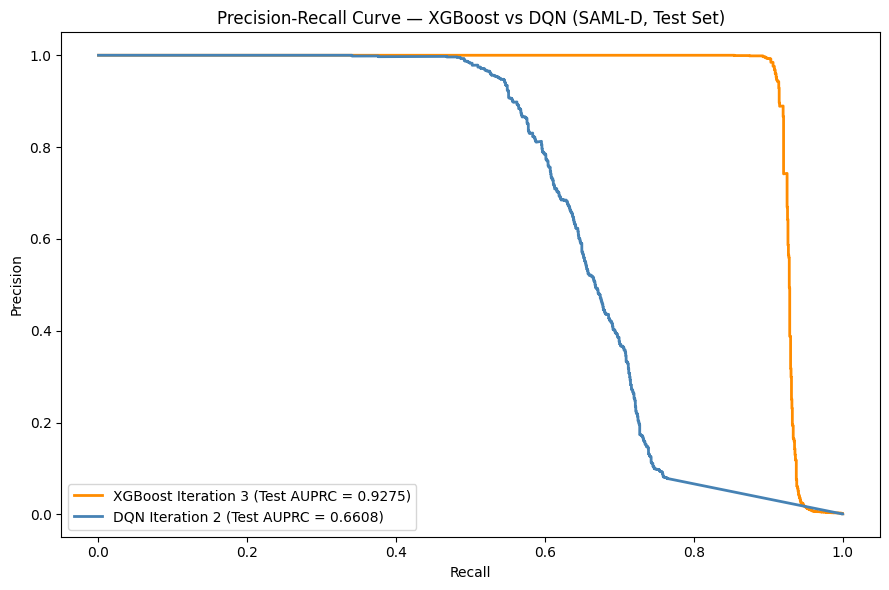

In [11]:
# [2b] Precision-Recall Curves
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_test_scores)
prec_dqn, rec_dqn, _ = precision_recall_curve(y_test, test_scores_v2)

plt.figure(figsize=(9, 6))
plt.plot(rec_xgb, prec_xgb, color='darkorange', lw=2,
         label=f'XGBoost Iteration 3 (Test AUPRC = {xgb_test_auprc:.4f})')
plt.plot(rec_dqn, prec_dqn, color='steelblue', lw=2,
         label=f'DQN Iteration 2 (Test AUPRC = {test_auprc_v2:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost vs DQN (SAML-D, Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/pr_curve_xgb_vs_dqn_test.png', dpi=150)
plt.show()

# 3. Explainability

## Global Feature Importance 
### XGBoost (n=2,500)
`pair_tx_count` dominates the XGBoost importance ranking with a mean |SHAP| of 5.52, nearly 3x the second-ranked feature `Payment_type` at 1.85. The remaining features form a long tail between 1.04 and 0.31.

### DQN (n=2,500)

The DQN importance scale reaches only 0.02 for the top-ranked feature `receiver_unique_senders`, with most remaining features contributing around 0.01. This is two orders of magnitude smaller than XGBoost, indicating that individual features have far less impact on the DQN's output. Notably, `pair_tx_count`, the dominant feature in XGBoost, ranks fifth with near-zero importance. The "Sum of 13 other features" bar at 0.03 is the largest in the plot, suggesting importance is spread thinly across many features rather than concentrated in a meaningful signal.

## Beeswarm 
### XGBoost (n=2,500)
The right side of `pair_tx_count` is entirely blue, meaning every transaction where the sender-receiver pair had no or little prior history was pushed toward suspicious without exception. The left side is less clean, with the majority being red but a notable blue minority, meaning an established relationship mostly pushes toward normal but not always. This asymmetry is meaningful: a new sender-receiver relationship is a near-certain suspicious signal, but a known relationship does not guarantee normality. Some laundering transactions occur between pairs that have transacted before.

`Payment_type` shows that certain payment types are consistently associated with higher suspicion scores. `sender_amount_std`, `receiver_tx_count`, `receiver_amount_std`, `sender_amount_min` and `receiver_amount_mean` primarily contribute to normal predictions, with low values of these features pushing toward normal. The remaining features show no clear patterns.

### DQN (n=2,500)
The DQN beeswarm looks very different from the XGBoost beeswarm. Almost all points cluster between -0.1 and +0.1, with a large mass sitting at zero. For the top-ranked features, high values (red) are consistently grouped together providing a directional push, while low values (blue) sit at zero or on the opposite side providing little signal. Medium values (purple) show almost no contribution in either direction, clustering entirely at zero. Overall the DQN beeswarm reflects a model that responds weakly and inconsistently to its input features, with no single feature producing the kind of clean, high-magnitude split visible in the XGBoost beeswarm.

## Individual Transactions
Ten transactions were selected from the test set, five laundering and five normal,  and analysed using SHAP waterfall plots for both models. The same transactions are used for both models to enable direct comparison. The plots show the raw suspiciousness score output by each model without applying a classification threshold.

### XGBoost
**Laundering transactions**

Two distinct detection pathways are visible across the five laundering transactions. In tx6024 (score 0.9998) and tx1986 (score 0.9972), `pair_tx_count = 0.0` is the dominant driver at +6.83 and +6.15 respectively, with the model recognising a new sender-receiver relationship as the primary suspicious signal.

In tx5022 (score 0.9999), tx3224 (score 0.9999) and tx2871 (score 0.9998), the pattern shifts entirely. `Cash Withdrawal` and `Cash Deposit` become the dominant drivers at +7.88, +7.70 and +7.97 respectively, while `pair_tx_count` at values of 10-12 actually pulls back negatively. The model has learned that cash-based payment instruments are highly suspicious regardless of relationship history.

**Normal transactions**

In tx0, tx2 and tx3, `pair_tx_count` values of 8-12 drive large negative contributions of -6.51, -6.69 and -5.55 respectively, with credit card and ACH payment types adding further negative push. In tx1 and tx4, `pair_tx_count = 0.0` initially pushes toward suspicious at +4.05 and +4.26, but `receiver_tx_count = 0.0` immediately counters, and the accumulation of negative contributions from amount statistics and payment type drags the score down to 0.0001. This is a key finding: XGBoost does not mechanically flag every transaction with `pair_tx_count = 0` as suspicious. It consults the full feature context before making a decision.

### DQN

**Laundering transactions**

The DQN only achieves meaningful suspiciousness scores when a cash-based payment type is present. tx5022 (score 0.8505) and tx3224 (score 0.8606) are the strongest detections, both driven by `Cash Withdrawal` contributing +0.16 and +0.09 respectively. tx2871 (score 0.7769) is similarly driven by `Cash Deposit` at +0.19.

In contrast, tx6024 and tx1986, which XGBoost scores at 0.9998 and 0.9972, receive DQN scores of only 0.5471 and 0.5007. For tx1986 specifically, the contributions cancel out almost perfectly, with every feature contributing between -0.03 and +0.03, resulting in a score indistinguishable from random. The DQN has completely failed to detect this transaction despite it being a confirmed laundering case.

**Normal transactions**

All five normal transactions score exactly 0.5007. Feature contributions are between -0.03 and +0.03 and cancel each other out in every case. The DQN does not differentiate normal transactions from each other, nor from some laundering transactions, producing scores that are practically indistinguishable from random guessing.


In [28]:
# ── [3.1] SHAP Setup ──────────────────────────────────────────────────────────
import shap
import numpy as np

SHAP_SAMPLE = 2500
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_xgb), SHAP_SAMPLE, replace=False)

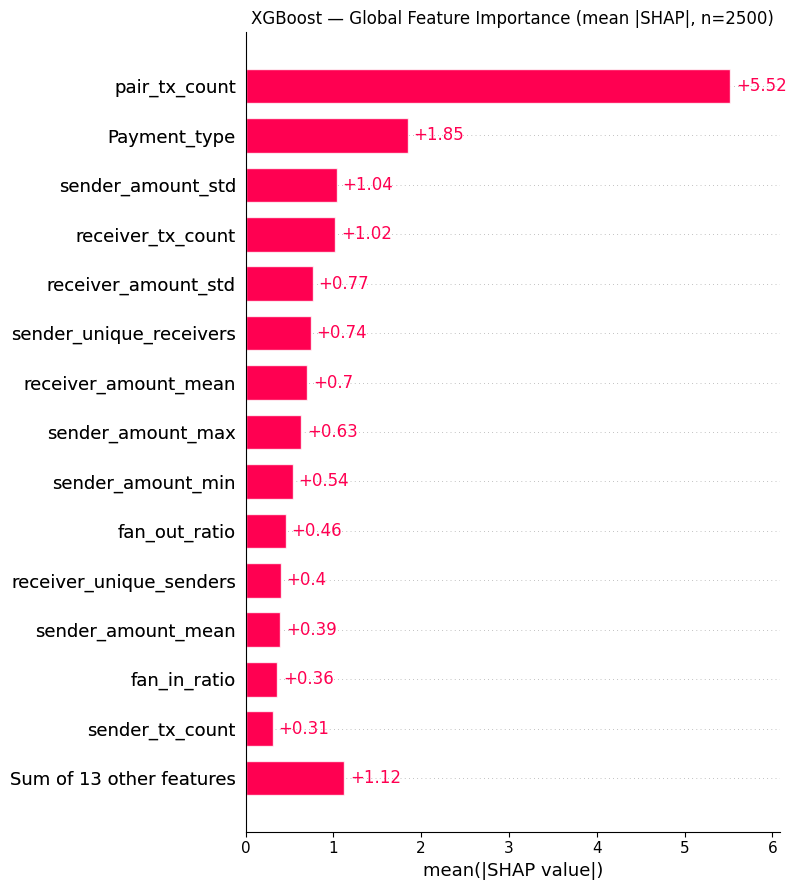

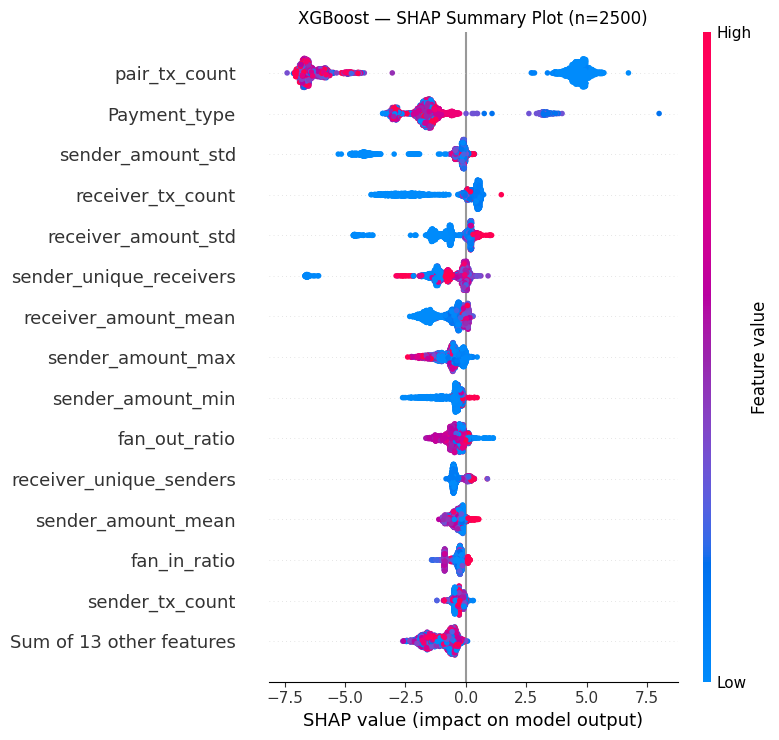

In [61]:
# ── [3.2] XGBoost Global Feature Importance ───────────────────────────────────
X_test_xgb_shap = X_test_xgb.iloc[sample_idx].copy()
for col in X_test_xgb_shap.select_dtypes('category').columns:
    X_test_xgb_shap[col] = X_test_xgb_shap[col].cat.codes

explainer_xgb   = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb(X_test_xgb_shap)

plt.figure()
shap.plots.bar(shap_values_xgb, max_display=15, show=False)
plt.title(f'XGBoost — Global Feature Importance (mean |SHAP|, n={SHAP_SAMPLE})')
plt.tight_layout()
plt.savefig('shap_xgb_global_bar.png', dpi=150)
plt.show()

plt.figure()
shap.plots.beeswarm(shap_values_xgb, max_display=15, show=False)
plt.title(f'XGBoost — SHAP Summary Plot (n={SHAP_SAMPLE})')
plt.tight_layout()
plt.savefig('shap_xgb_beeswarm.png', dpi=150)
plt.show()

  0%|          | 0/2500 [00:00<?, ?it/s]

c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:755: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 44 iterations, alpha=8.222e-05, previous alpha=8.093e-05, with an active set of 33 regressors.
  warnings.warn(
c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 24 iterations, i.e. alpha=1.522e-04, with an active set of 24 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:755: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 40 iterations, alpha=8.187e-05, previous al

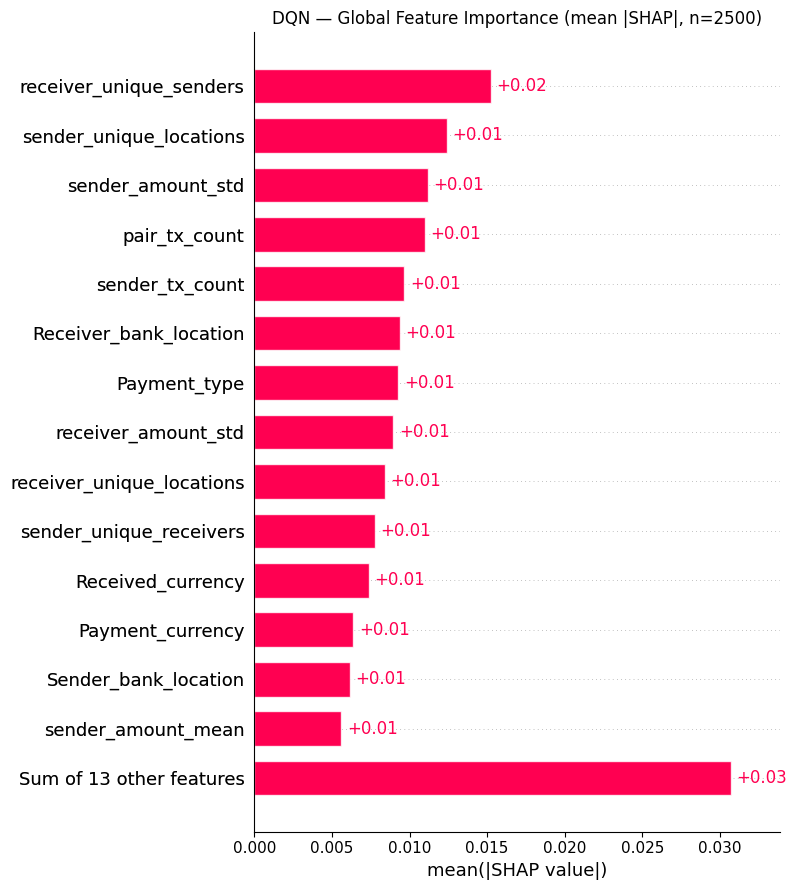

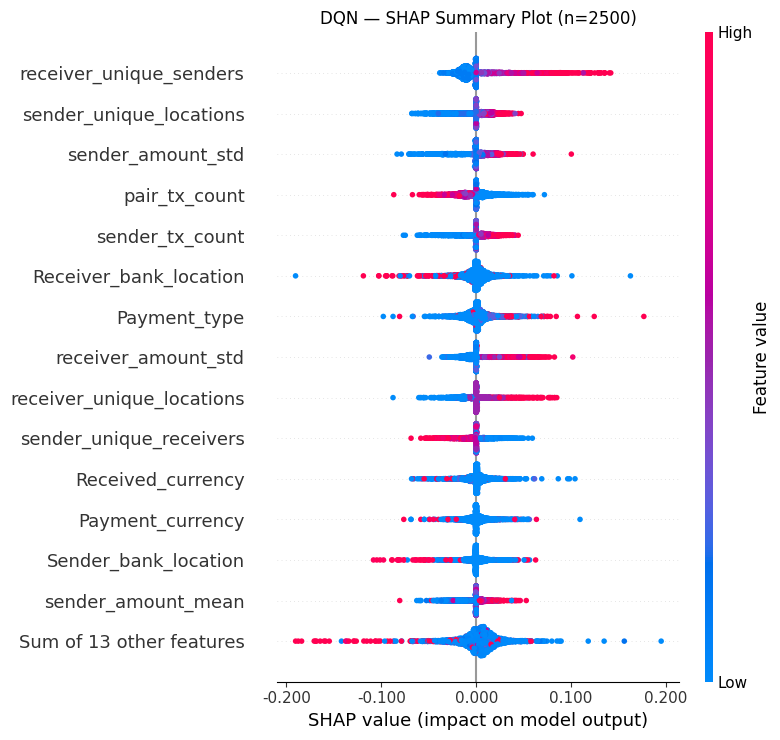

In [17]:
# ── [3.3] DQN Global Feature Importance ──────────────────────────────────────
CAT_COLS      = ['Payment_currency', 'Received_currency',
                 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
feature_names = X_train_enc.columns.tolist()

background = X_test_sc[np.random.choice(len(X_test_sc), 100, replace=False)]

def dqn_predict(X):
    agent_v2.q_network.eval()
    with torch.no_grad():
        t     = torch.FloatTensor(X).to(DEVICE)
        q     = agent_v2.q_network(t)
        probs = torch.softmax(q, dim=1)[:, 1]
    return probs.cpu().numpy()

explainer_dqn       = shap.KernelExplainer(dqn_predict, background)
X_test_sc_sample    = X_test_sc[sample_idx]
shap_values_dqn_raw = explainer_dqn.shap_values(X_test_sc_sample, nsamples=100)

# Aggregate one-hot back to categorical
aggregated_names = []
aggregated_shap  = []
used = set()

for col in feature_names:
    parent = next((c for c in CAT_COLS if col.startswith(c + '_')), None)
    if parent and parent not in used:
        cols = [i for i, f in enumerate(feature_names) if f.startswith(parent + '_')]
        aggregated_shap.append(shap_values_dqn_raw[:, cols].sum(axis=1))
        aggregated_names.append(parent)
        used.add(parent)
    elif parent is None and col not in used:
        idx = feature_names.index(col)
        aggregated_shap.append(shap_values_dqn_raw[:, idx])
        aggregated_names.append(col)
        used.add(col)

shap_values_dqn = np.column_stack(aggregated_shap)

shap_explanation_dqn = shap.Explanation(
    values        = shap_values_dqn,
    base_values   = np.full(len(shap_values_dqn), explainer_dqn.expected_value),
    data          = np.column_stack([
                        X_test_sc_sample[:, feature_names.index(c)]
                        if c not in CAT_COLS else
                        X_test_sc_sample[:, [i for i, f in enumerate(feature_names) if f.startswith(c + '_')]].sum(axis=1)
                        for c in aggregated_names
                    ]),
    feature_names = aggregated_names
)

plt.figure()
shap.plots.bar(shap_explanation_dqn, max_display=15, show=False)
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
plt.title(f'DQN — Global Feature Importance (mean |SHAP|, n={SHAP_SAMPLE})')
plt.tight_layout()
plt.savefig('shap_dqn_global_bar.png', dpi=150)
plt.show()

plt.figure()
shap.plots.beeswarm(shap_explanation_dqn, max_display=15, show=False)
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
plt.title(f'DQN — SHAP Summary Plot (n={SHAP_SAMPLE})')
plt.tight_layout()
plt.savefig('shap_dqn_beeswarm.png', dpi=150)
plt.show()

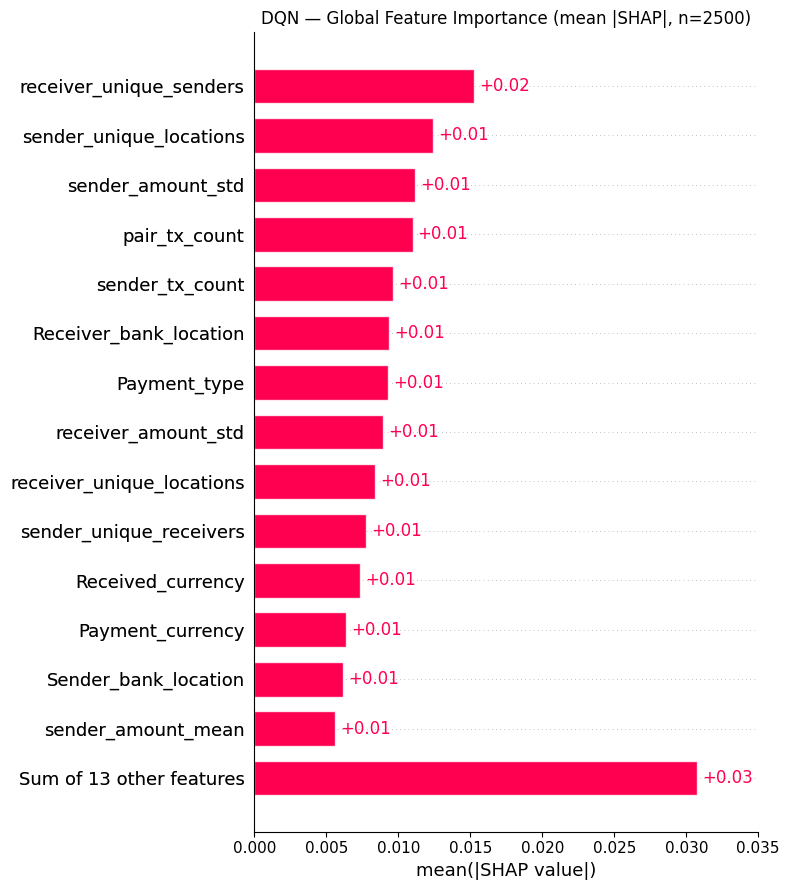

In [19]:
plt.figure()
shap.plots.bar(shap_explanation_dqn, max_display=15, show=False)
plt.xlim(0, 0.035)
plt.title(f'DQN — Global Feature Importance (mean |SHAP|, n={SHAP_SAMPLE})')
plt.tight_layout()
plt.savefig('shap_dqn_global_bar.png', dpi=150)
plt.show()

## Individual Transactions

In [50]:
# ── [3.4] Select transactions ─────────────────────────────────────────────────
laundering_ids = np.where(y_test == 1)[0][:5]
normal_ids     = np.where(y_test == 0)[0][:5]
TX_IDS         = np.concatenate([laundering_ids, normal_ids])
print(f'Laundering transactions: {laundering_ids}')
print(f'Normal transactions    : {normal_ids}')

Laundering transactions: [1986 2871 3224 5022 6024]
Normal transactions    : [0 1 2 3 4]


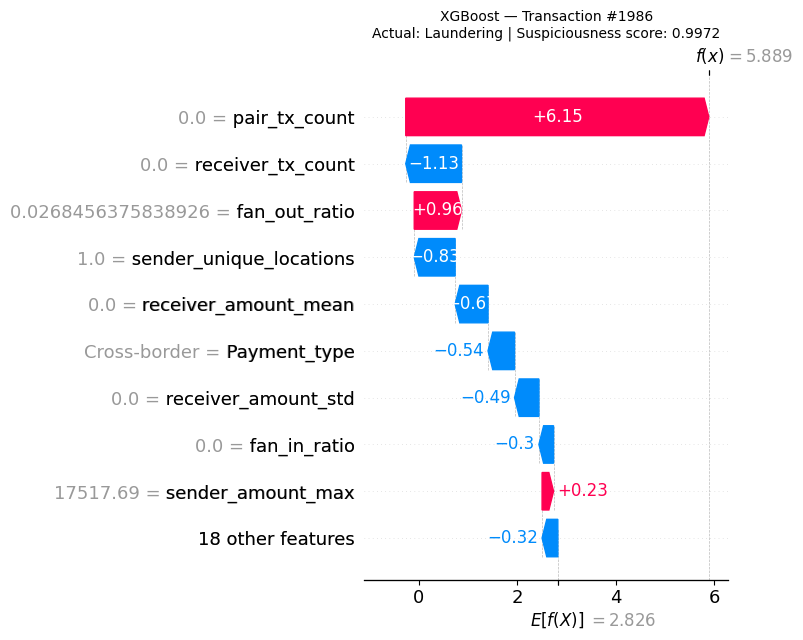

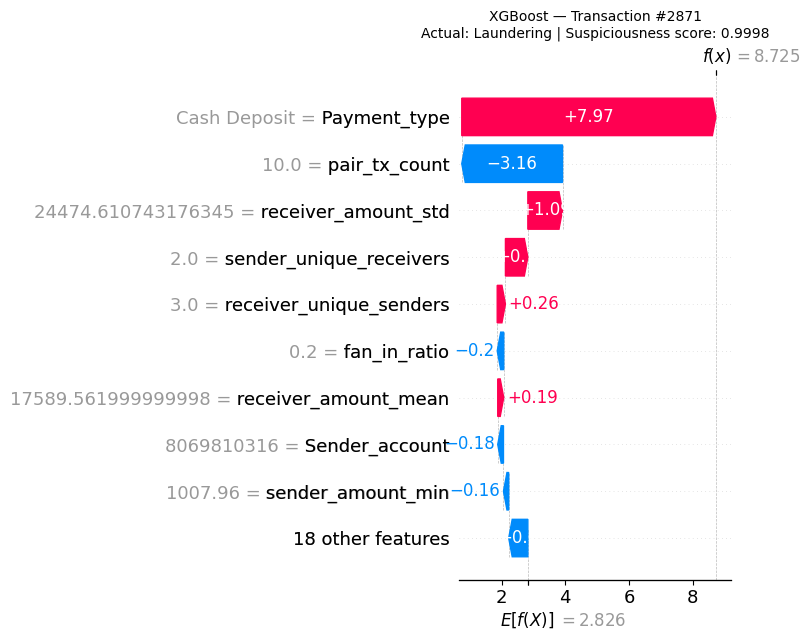

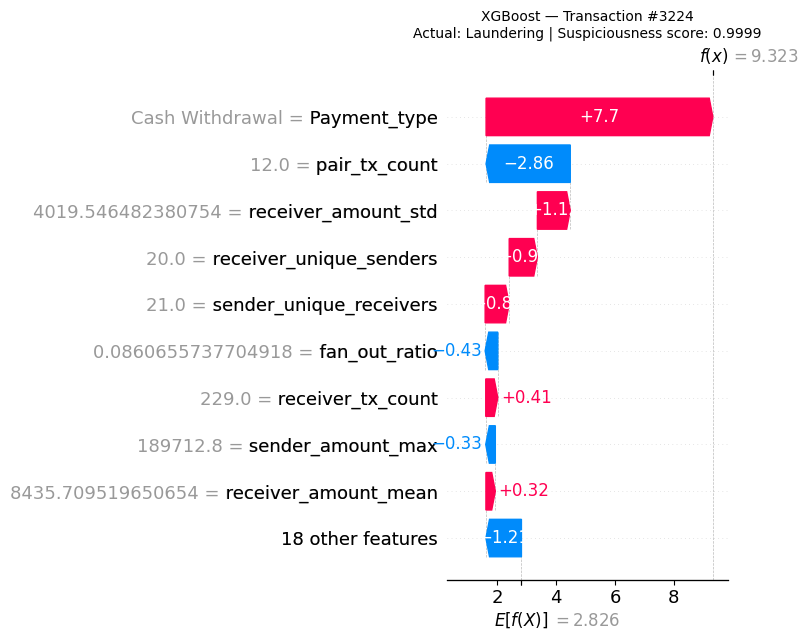

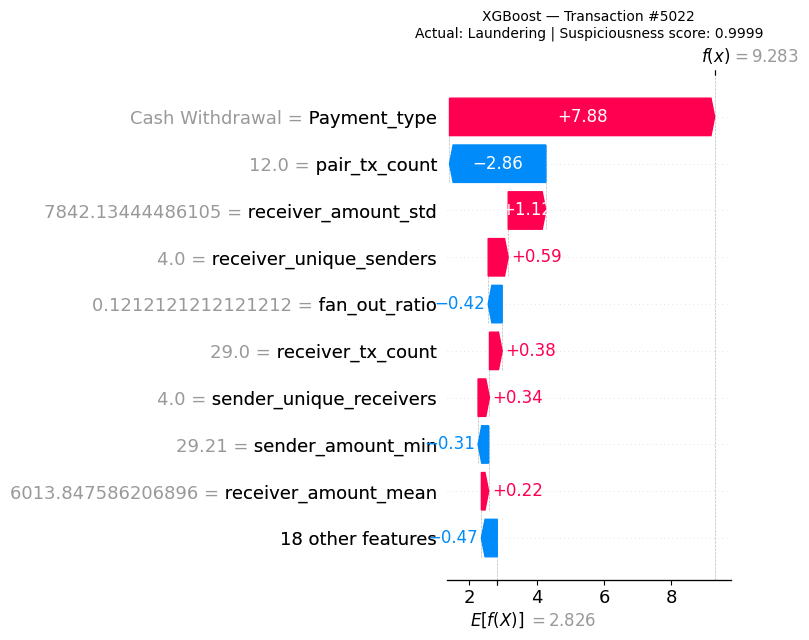

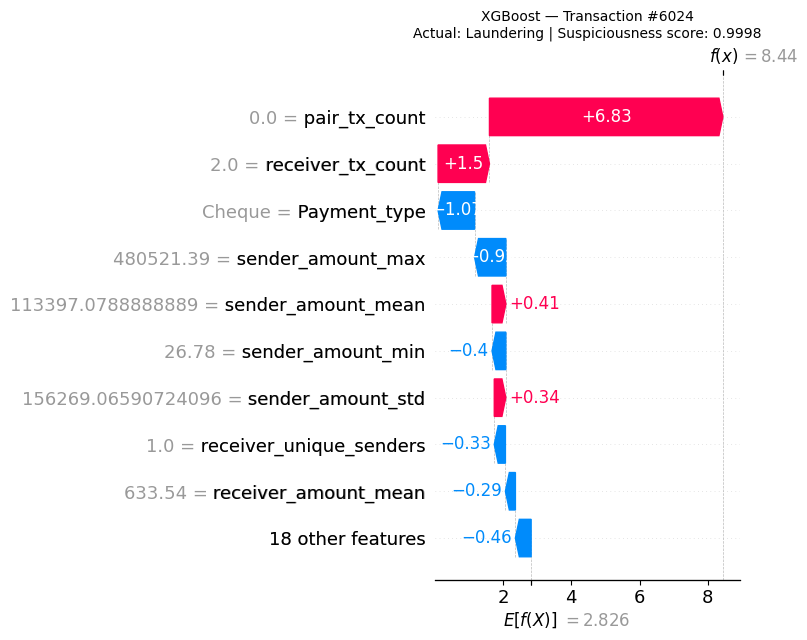

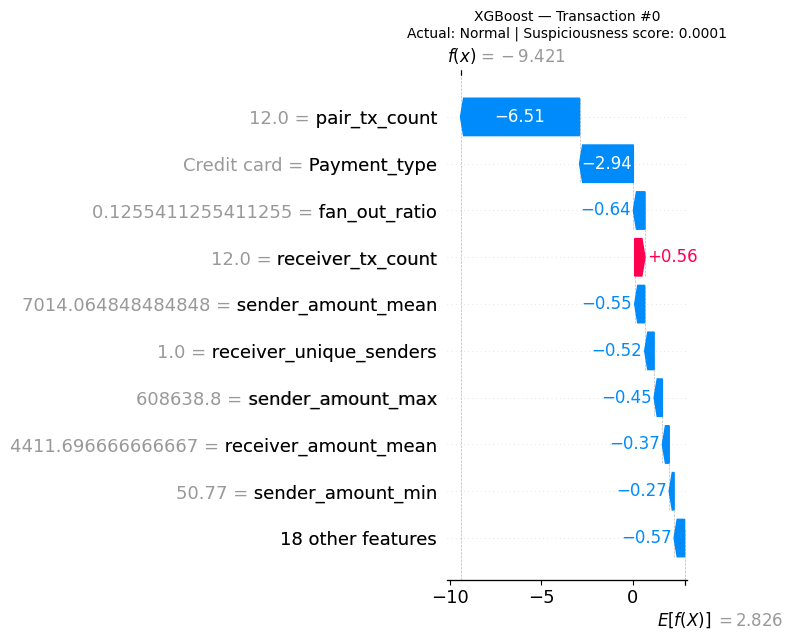

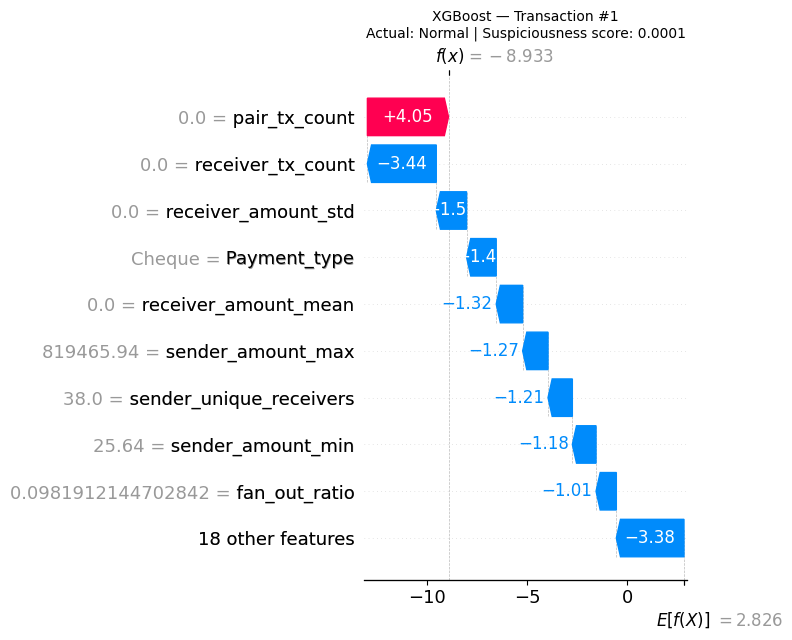

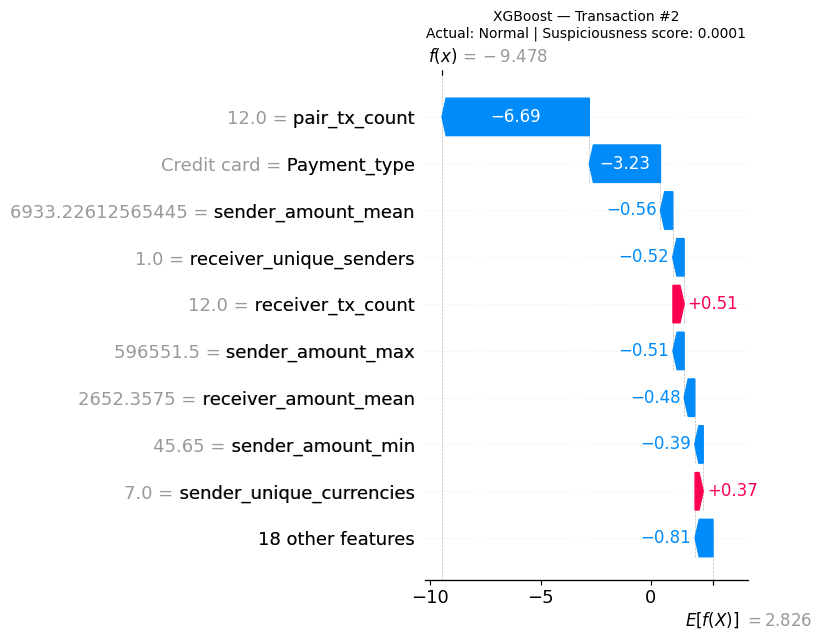

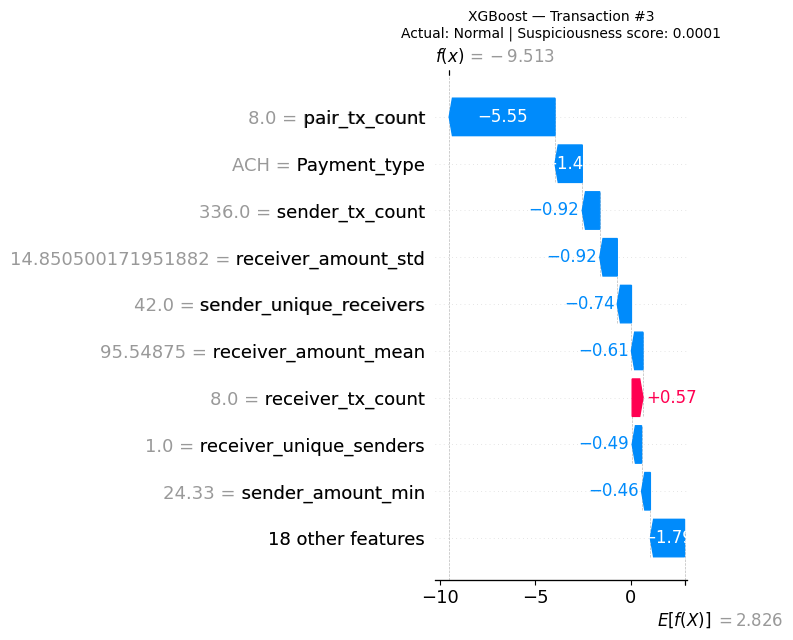

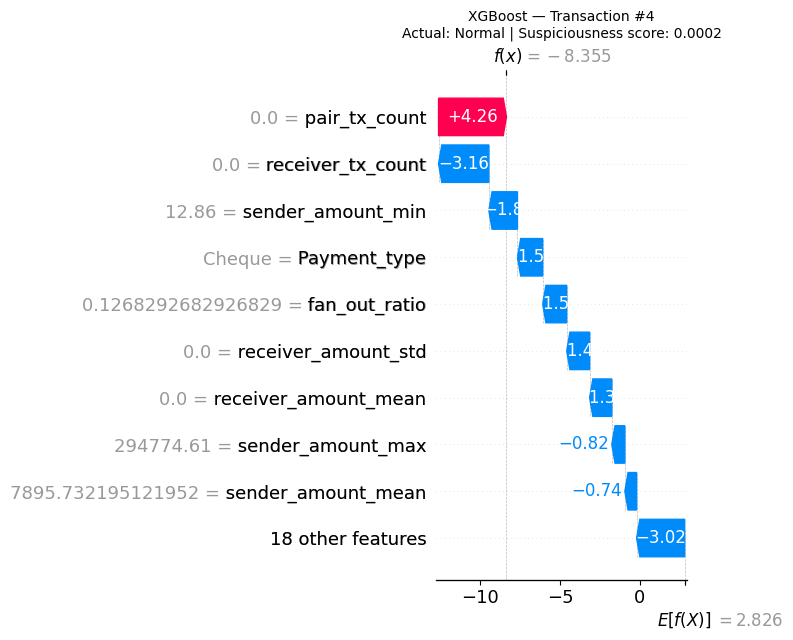

In [51]:
# ── [3.5] XGBoost — single transaction waterfall ─────────────────────────────
for TX_ID in TX_IDS:
    X_test_xgb_single = X_test_xgb.iloc[[TX_ID]].copy()
    for col in X_test_xgb_single.select_dtypes('category').columns:
        X_test_xgb_single[col] = X_test_xgb_single[col].cat.codes

    shap_single_xgb = explainer_xgb(X_test_xgb_single)

    original_values = []
    for feat in shap_single_xgb.feature_names:
        if feat in CAT_COLS:
            original_values.append(str(test_df.iloc[TX_ID][feat]))
        else:
            original_values.append(test_df.iloc[TX_ID][feat])

    shap_single_xgb_display = shap.Explanation(
        values        = shap_single_xgb.values[0],
        base_values   = shap_single_xgb.base_values[0],
        data          = np.array(original_values),
        feature_names = shap_single_xgb.feature_names
    )

    plt.figure()
    shap.plots.waterfall(shap_single_xgb_display, show=False)
    plt.title(
        f'XGBoost — Transaction #{TX_ID}\n'
        f'Actual: {"Laundering" if y_test[TX_ID] == 1 else "Normal"} | '
        f'Suspiciousness score: {xgb_test_scores[TX_ID]:.4f}',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig(f'shap_xgb_waterfall_tx{TX_ID}.png', dpi=150)
    plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

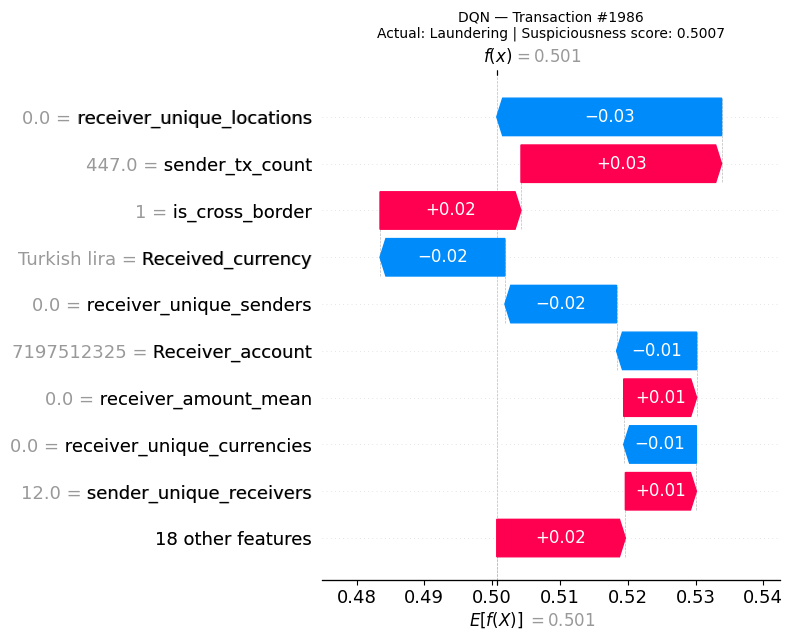

  0%|          | 0/1 [00:00<?, ?it/s]

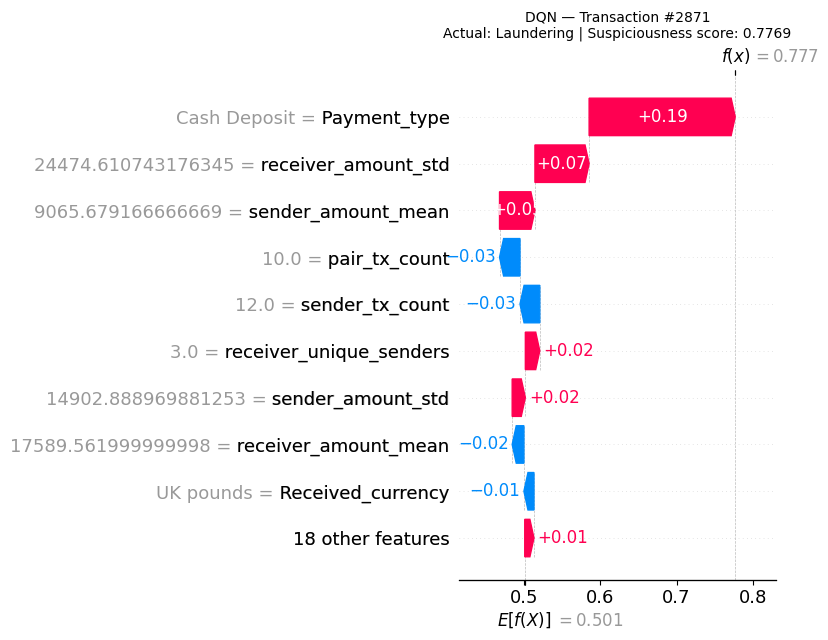

  0%|          | 0/1 [00:00<?, ?it/s]

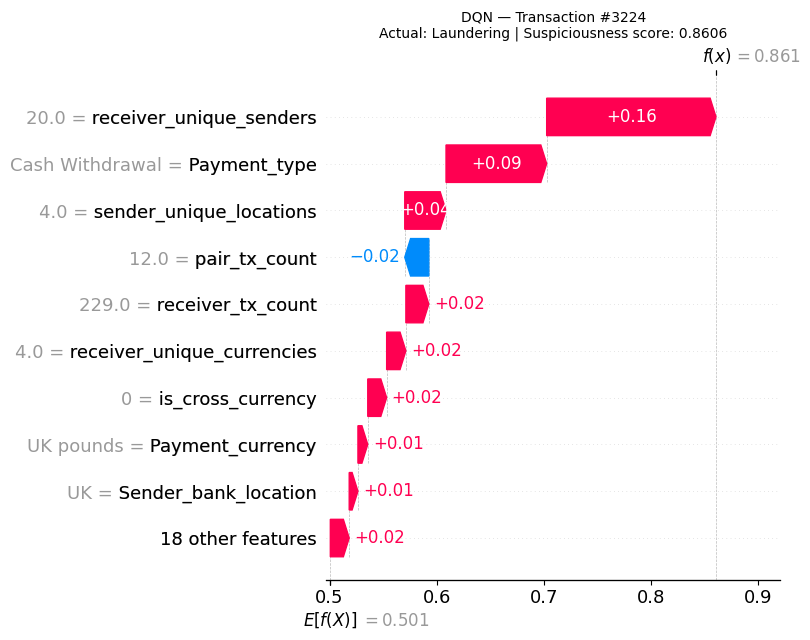

  0%|          | 0/1 [00:00<?, ?it/s]

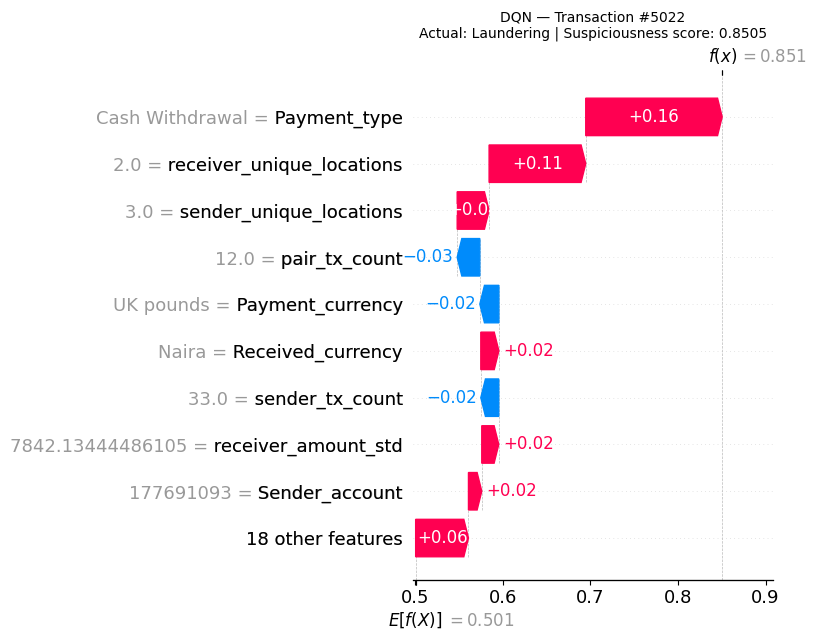

  0%|          | 0/1 [00:00<?, ?it/s]

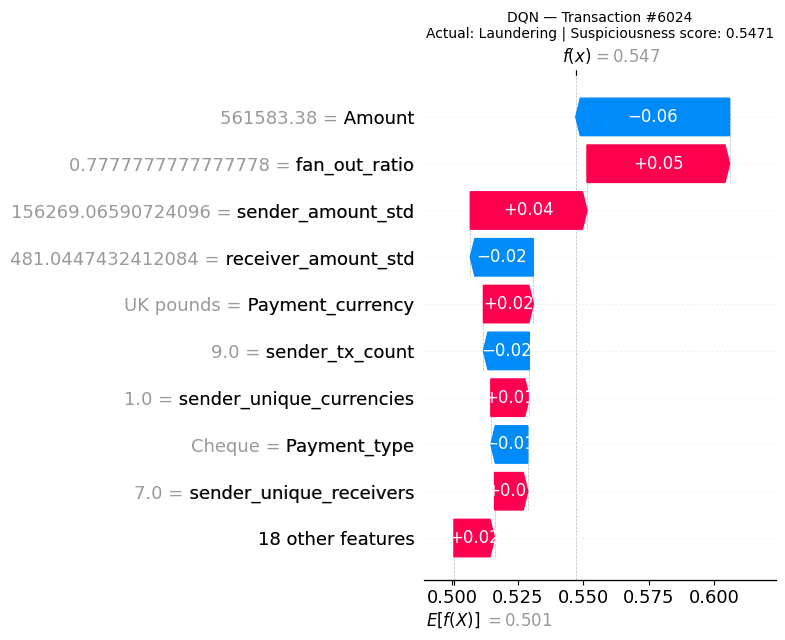

  0%|          | 0/1 [00:00<?, ?it/s]

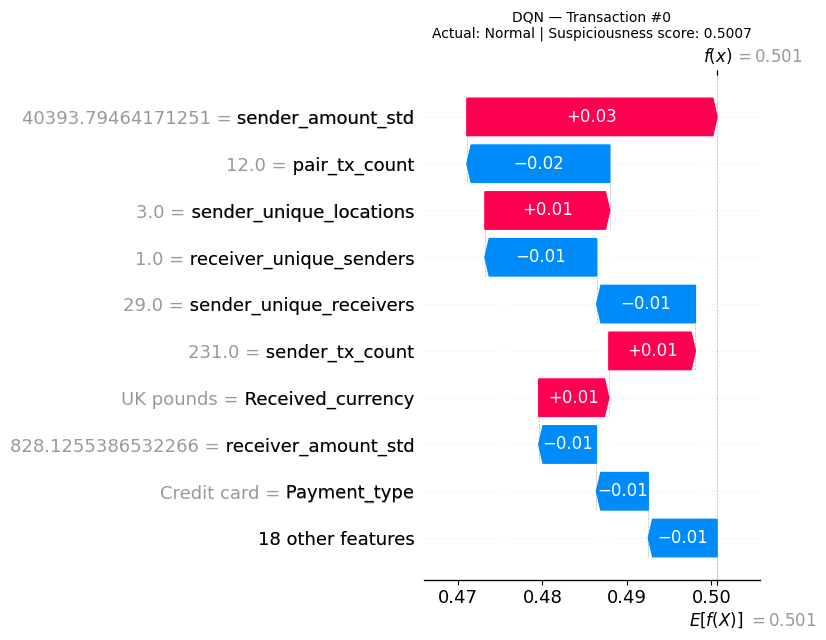

  0%|          | 0/1 [00:00<?, ?it/s]

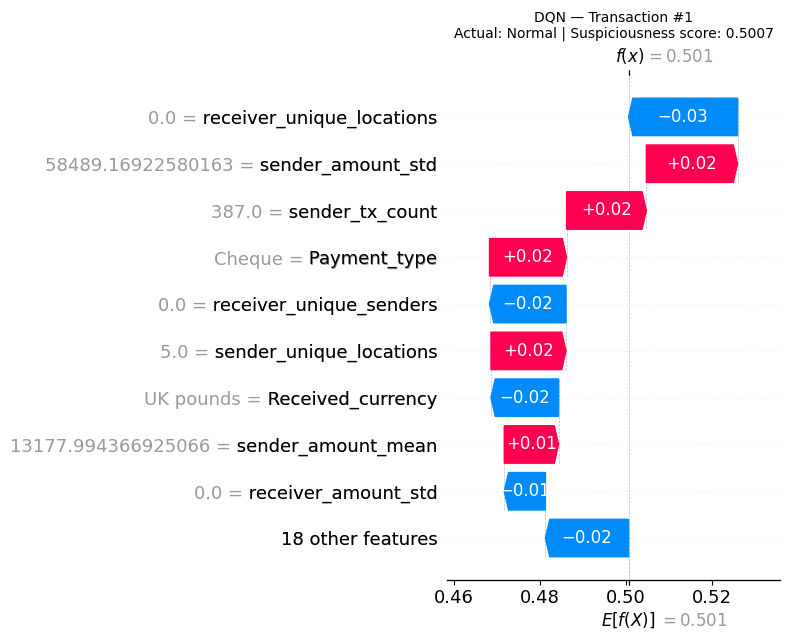

  0%|          | 0/1 [00:00<?, ?it/s]

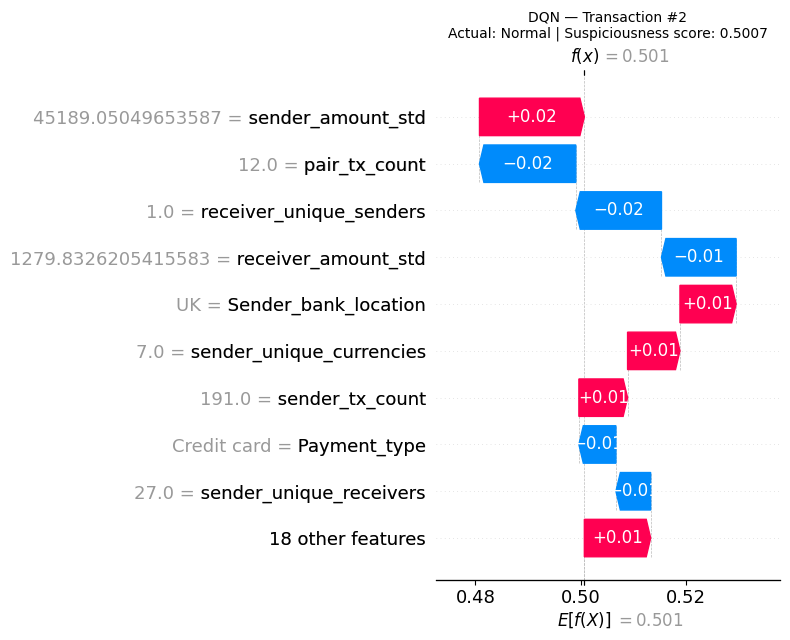

  0%|          | 0/1 [00:00<?, ?it/s]

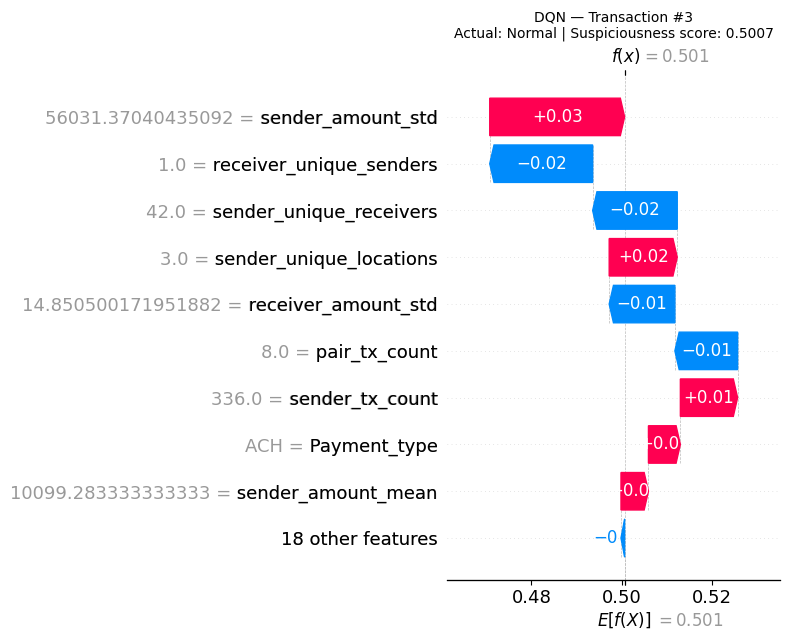

  0%|          | 0/1 [00:00<?, ?it/s]

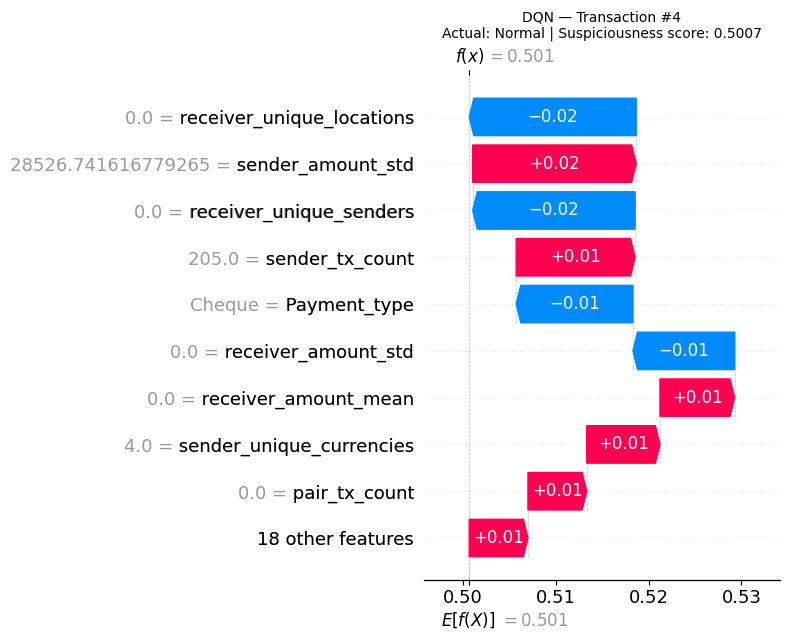


Transactions compared: [1986 2871 3224 5022 6024    0    1    2    3    4]
  #1986 — XGBoost: 0.9972 | DQN: 0.5007
  #2871 — XGBoost: 0.9998 | DQN: 0.7769
  #3224 — XGBoost: 0.9999 | DQN: 0.8606
  #5022 — XGBoost: 0.9999 | DQN: 0.8505
  #6024 — XGBoost: 0.9998 | DQN: 0.5471
  #0 — XGBoost: 0.0001 | DQN: 0.5007
  #1 — XGBoost: 0.0001 | DQN: 0.5007
  #2 — XGBoost: 0.0001 | DQN: 0.5007
  #3 — XGBoost: 0.0001 | DQN: 0.5007
  #4 — XGBoost: 0.0002 | DQN: 0.5007


In [52]:
# ── [3.6] DQN — single transaction waterfall ─────────────────────────────────
for TX_ID in TX_IDS:
    shap_single_dqn_raw = explainer_dqn.shap_values(X_test_sc[[TX_ID]], nsamples=200)

    aggregated_single = []
    data_single       = []

    for col in aggregated_names:
        if col in CAT_COLS:
            cols = [i for i, f in enumerate(feature_names) if f.startswith(col + '_')]
            aggregated_single.append(shap_single_dqn_raw[0, cols].sum())
            data_single.append(str(test_df.iloc[TX_ID][col]))
        else:
            idx = feature_names.index(col)
            aggregated_single.append(shap_single_dqn_raw[0, idx])
            data_single.append(test_df.iloc[TX_ID][col])

    shap_single_dqn = shap.Explanation(
        values        = np.array(aggregated_single),
        base_values   = explainer_dqn.expected_value,
        data          = np.array(data_single),
        feature_names = aggregated_names
    )

    plt.figure()
    shap.plots.waterfall(shap_single_dqn, show=False)
    plt.title(
        f'DQN — Transaction #{TX_ID}\n'
        f'Actual: {"Laundering" if y_test[TX_ID] == 1 else "Normal"} | '
        f'Suspiciousness score: {test_scores_v2[TX_ID]:.4f}',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig(f'shap_dqn_waterfall_tx{TX_ID}.png', dpi=150)
    plt.show()

print(f'\nTransactions compared: {TX_IDS}')
for TX_ID in TX_IDS:
    print(f'  #{TX_ID} — XGBoost: {xgb_test_scores[TX_ID]:.4f} | DQN: {test_scores_v2[TX_ID]:.4f}')

# 4. Robustness

## 4.1 Hyperparameter Sensitivity

XGBoost proved largely insensitive to hyperparameter choices. Across three iterations covering a wide grid search of 150 combinations and 100 trials of Bayesian optimisation, the validation AUPRC improved from 0.9087 (defaults) to 0.9107 (grid search) to 0.9136 (Bayesian optimisation), a total gain of only 0.0049. Test AUPRC followed the same pattern: 0.9232, 0.9260 and 0.9275. This suggests the model reaches near-optimal performance with default settings and that continued tuning yields minimal returns.

The DQN showed greater sensitivity to individual parameter changes. Switching the reward function from Lin et al. to Zhinin-Vera et al. (changing only λ and γ) moved validation AUPRC from 0.5994 to 0.6203. Adjusting epsilon decay alone caused a validation drop from 0.6203 to 0.6132. Adding dropout at p = 0.5 caused a more significant decline to 0.5598, and reducing it to p = 0.2 partially recovered performance to 0.5914. Single parameter changes consistently produced noticeable shifts, indicating the DQN is considerably more sensitive to its configuration than XGBoost. On the test set, the same pattern holds. The reward function switch improved test AUPRC from 0.6450 to 0.6608. Epsilon decay produced a marginal test improvement to 0.6691 despite the validation decline. Dropout at p = 0.5 dropped test AUPRC to 0.5578, recovering partially to 0.6197 at p = 0.2.

## 4.2 Reproducibility

Beyond hyperparameter choices, the DQN also exhibits run-to-run variability. Due to the stochastic nature of experience replay, epsilon-greedy exploration and neural network weight initialisation, rerunning the same configuration can produce differences of approximately ±0.03 in AUPRC even with a fixed random seed. XGBoost, by contrast, is fully deterministic and produces identical results on every run.

## 4.3 Score Distribution

XGBoost produces highly decisive suspiciousness scores. Across the ten transactions analysed in the explainability section, laundering transactions received scores between 0.9972 and 0.9999, while normal transactions received scores between 0.0001 and 0.0002. The model commits strongly to its predictions in both directions, leaving little ambiguity for investigators.

The DQN's score distribution is considerably more compressed. Laundering transactions scored between 0.5007 and 0.8606, with the higher scores only occurring when a cash-based payment type was present. Normal transactions all scored exactly 0.5007, indistinguishable from the lowest-scoring laundering transactions. In practice, this means the DQN's output provides little basis for prioritising alerts, as the score range offers almost no differentiation between suspicious and normal cases.

# 5. Scalability
## 5.1 Training Time
- Training time xgboost 31.7s, 
- training time xgboost grid search 56m 59s
- training time xgboost bayesian optimization 38m 7s
- dqn it1 41m 
- dqn it2 39.8m = 39m 48s
- dqn it3 36.9m = 36m 54s
- dqn it4 63.1m = 63m 6s
- dqn it5 46.2m = 46m 12s

- single inference
- scaling to more data
- retrain vs keep training
- model size

In [17]:
import time

best_params = {
    'eta': 0.23811612043960928,
    'subsample': 0.26462546715504953,
    'min_child_weight': 4,
    'booster': 'gbtree',
    'scale_pos_weight': 982,
    'eval_metric': 'aucpr',
    'early_stopping_rounds': 50,
    'enable_categorical': True,
    'random_state': 42,
    'device': 'cuda'
}

model = xgb.XGBClassifier(**best_params)

start = time.time()

model.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
elapsed = time.time() - start

print(f'Training time: {elapsed:.1f}s')

Training time: 25.7s


# 6. Model Complexity

# 7. Resource Demand

In [21]:
import json
with open('../XGBoost/models/xgboost_aml_optuna.json') as f:
    model_json = json.load(f)
print(model_json['learner']['attributes'])

{'best_iteration': '35', 'best_score': '0.9136236840358793', 'scikit_learn': '{"_estimator_type": "classifier"}'}


In [35]:
import time
import numpy as np

# ── Single transaction inference ──────────────────────────────────────────────
single_tx = X_test_xgb.iloc[[0]]

# Warmup
model.predict_proba(single_tx)

start = time.time()
for _ in range(1000):
    model.predict_proba(single_tx)
elapsed = (time.time() - start) / 1000

print(f'XGBoost single transaction inference: {elapsed*1000:.4f} ms')

# ── 10,000 transaction inference ──────────────────────────────────────────────
batch_10k = X_test_xgb.iloc[:10000]

start = time.time()
model.predict_proba(batch_10k)
elapsed = time.time() - start

print(f'XGBoost 10,000 transaction inference: {elapsed:.4f}s')

# ── SHAP for single transaction ───────────────────────────────────────────────
single_tx_shap = single_tx.copy()
for col in single_tx_shap.select_dtypes('category').columns:
    single_tx_shap[col] = single_tx_shap[col].cat.codes

explainer = shap.TreeExplainer(model)

start = time.time()
shap_values = explainer(single_tx_shap)
elapsed = time.time() - start

print(f'XGBoost SHAP single transaction: {elapsed:.4f}s')

XGBoost single transaction inference: 17.8993 ms
XGBoost 10,000 transaction inference: 0.0522s
XGBoost SHAP single transaction: 0.0335s


In [25]:
# ── DQN single transaction inference ─────────────────────────────────────────
agent_v2.q_network.load_state_dict(torch.load('../DQN/models/dqn_v2_best.pt', map_location=DEVICE))
agent_v2.q_network.eval()

single_tx_dqn = X_test_sc[[0]]

# Warmup
agent_v2.get_scores(single_tx_dqn)

start = time.time()
for _ in range(1000):
    agent_v2.get_scores(single_tx_dqn)
elapsed = (time.time() - start) / 1000

print(f'DQN single transaction inference: {elapsed*1000:.4f} ms')

# ── DQN 10,000 transaction inference ─────────────────────────────────────────
batch_10k_dqn = X_test_sc[:1000000]

start = time.time()
agent_v2.get_scores(batch_10k_dqn)
elapsed = time.time() - start

print(f'DQN 10,000 transaction inference: {elapsed:.4f}s')

# ── DQN SHAP single transaction ───────────────────────────────────────────────
single_tx_background = X_test_sc[np.random.choice(len(X_test_sc), 100, replace=False)]

def dqn_predict(X):
    agent_v2.q_network.eval()
    with torch.no_grad():
        t     = torch.FloatTensor(X).to(DEVICE)
        q     = agent_v2.q_network(t)
        probs = torch.softmax(q, dim=1)[:, 1]
    return probs.cpu().numpy()

explainer_dqn_single = shap.KernelExplainer(dqn_predict, single_tx_background)

start = time.time()
shap_values_single = explainer_dqn_single.shap_values(X_test_sc[[0]], nsamples=100)
elapsed = time.time() - start

print(f'DQN SHAP single transaction: {elapsed:.4f}s')

DQN single transaction inference: 1.0092 ms
DQN 10,000 transaction inference: 0.4170s


  0%|          | 0/1 [00:00<?, ?it/s]

DQN SHAP single transaction: 0.4406s


In [32]:
# ── [3.2] XGBoost Global Feature Importance ───────────────────────────────────
X_test_xgb_shap = X_test_xgb.iloc[sample_idx].copy()
for col in X_test_xgb_shap.select_dtypes('category').columns:
    X_test_xgb_shap[col] = X_test_xgb_shap[col].cat.codes

explainer_xgb   = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb(X_test_xgb_shap)

CAT_COLS      = ['Payment_currency', 'Received_currency',
                 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
feature_names = X_train_enc.columns.tolist()

background = X_test_sc[np.random.choice(len(X_test_sc), 100, replace=False)]
explainer_dqn       = shap.KernelExplainer(dqn_predict, background)
X_test_sc_sample    = X_test_sc[sample_idx]
shap_values_dqn_raw = explainer_dqn.shap_values(X_test_sc_sample, nsamples=100)


# XGBoost
start = time.time()
shap_values = explainer_xgb(X_test_xgb_shap)
elapsed = time.time() - start
print(f'XGBoost SHAP 2500 transactions: {elapsed:.2f}s')

# DQN
start = time.time()
shap_values_dqn_raw = explainer_dqn.shap_values(X_test_sc_sample, nsamples=100)
elapsed = time.time() - start
print(f'DQN SHAP 2500 transactions: {elapsed:.2f}s')

  0%|          | 0/2500 [00:00<?, ?it/s]

c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 15 iterations, i.e. alpha=5.483e-04, with an active set of 13 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 25 iterations, i.e. alpha=1.440e-04, with an active set of 23 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:755: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 27 iterations, 

XGBoost SHAP 2500 transactions: 0.09s


  0%|          | 0/2500 [00:00<?, ?it/s]

c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 15 iterations, i.e. alpha=2.055e-04, with an active set of 15 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:755: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 28 iterations, alpha=7.447e-05, previous alpha=6.217e-05, with an active set of 27 regressors.
  warnings.warn(
c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\linear_model\_least_angle.py:725: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 43 iterations, i.e. alpha=2.122e-05, with an active set of 33 regressors, and the smallest chol

DQN SHAP 2500 transactions: 871.04s


In [33]:
import time

start = time.time()
shap_values_xgb = explainer_xgb(X_test_xgb_shap)
elapsed = time.time() - start
print(f'XGBoost SHAP {SHAP_SAMPLE} transactions: {elapsed:.2f}s')

XGBoost SHAP 2500 transactions: 0.25s


# Dicussion Plots   


In [14]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# XGBoost predictions
y_test_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_test_xgb = y_test  # your test labels

def recall_at_95(y_true, y_proba, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    
    # Find index closest to recall = 0.95
    idx = np.argmin(np.abs(recall - 0.95))
    
    print(f"\n{model_name}")
    print(f"  Threshold:              {thresholds[idx]:.4f}")
    print(f"  Recall at threshold:    {recall[idx]:.4f}")
    print(f"  Precision at threshold: {precision[idx]:.4f}")
    print(f"  False positives per true positive: {(1 - precision[idx]) / precision[idx]:.1f}")

# XGBoost
recall_at_95(y_test_xgb, y_test_proba_xgb, "XGBoost Iteration 3")


XGBoost Iteration 3
  Threshold:              0.0744
  Recall at threshold:    0.9499
  Precision at threshold: 0.0161
  False positives per true positive: 61.0


In [16]:
import numpy as np
from sklearn.metrics import precision_recall_curve
import torch
import torch.nn.functional as F

def recall_at_95(y_true, y_proba, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    idx = np.argmin(np.abs(recall - 0.95))
    print(f"\n{model_name}")
    print(f"  Threshold:              {thresholds[idx]:.4f}")
    print(f"  Recall at threshold:    {recall[idx]:.4f}")
    print(f"  Precision at threshold: {precision[idx]:.4f}")
    print(f"  False positives per true positive: {(1 - precision[idx]) / precision[idx]:.1f}")

# XGBoost
y_test_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]
recall_at_95(y_test, y_test_proba_xgb, "XGBoost Iteration 3")

# DQN
agent_v2.q_network.eval()
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_test_sc).to(DEVICE)
    q_values = agent_v2.q_network(X_tensor)
    probs = F.softmax(q_values, dim=1)
    y_test_proba_dqn = probs[:, 1].cpu().numpy()
recall_at_95(y_test, y_test_proba_dqn, "DQN Iteration 2")


XGBoost Iteration 3
  Threshold:              0.0744
  Recall at threshold:    0.9499
  Precision at threshold: 0.0161
  False positives per true positive: 61.0

DQN Iteration 2
  Threshold:              0.5007
  Recall at threshold:    0.9982
  Precision at threshold: 0.0012
  False positives per true positive: 835.0


In [18]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [20]:
import json
with open('../Prototype/models/feature_names.json', 'w') as f:
    json.dump(X_train_enc.columns.tolist(), f)